<a href="https://colab.research.google.com/github/noureldin75/RetinaGrade/blob/nour/nootbooks/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

if os.path.exists('/content/RetinaGrade'):
    %cd /content/RetinaGrade
    !git pull origin nour
else:
    !git clone -b nour https://github.com/noureldin75/RetinaGrade.git
    %cd RetinaGrade

/content/RetinaGrade
From https://github.com/noureldin75/RetinaGrade
 * branch            nour       -> FETCH_HEAD
Already up to date.


In [2]:
!mkdir -p data notebooks src

In [24]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle competitions download -c aptos2019-blindness-detection -p ./data

!unzip -q ./data/aptos2019-blindness-detection.zip -d ./data

100% 9.51G/9.51G [07:59<00:00, 21.3MB/s]



In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

train_df=pd.read_csv('./data/train.csv')
print(f"Shape: {train_df.shape}")
print(f"Columns: {train_df.columns.tolist()}")
print(f"Missing values: {train_df.isnull().sum()}\n")
print(train_df.head())


Shape: (3662, 2)
Columns: ['id_code', 'diagnosis']
Missing values: id_code      0
diagnosis    0
dtype: int64

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0


In [4]:
print(f"{train_df['diagnosis'].value_counts().sort_index()}")


diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [5]:
# --- Verify every listed image actually exists on disk ---
image_dir = './data/train_images'
missing_files = []

for img_id in train_df['id_code']:
    # APTOS images are .png
    path = os.path.join(image_dir, f"{img_id}.png")
    if not os.path.exists(path):
        missing_files.append(img_id)

print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])  # show a sample


Images listed in CSV: 3662
Missing image files: 0


In [6]:
image_dir='./data/train_images'
missing_images=[]
for id in train_df['id_code']:
  path=os.path.join(image_dir,f"{id}.png")
  if not os.path.exists(path):
    missing_files.append(id)
print(f"\nImages listed in CSV: {len(train_df)}")
print(f"Missing image files: {len(missing_files)}")


Images listed in CSV: 3662
Missing image files: 0


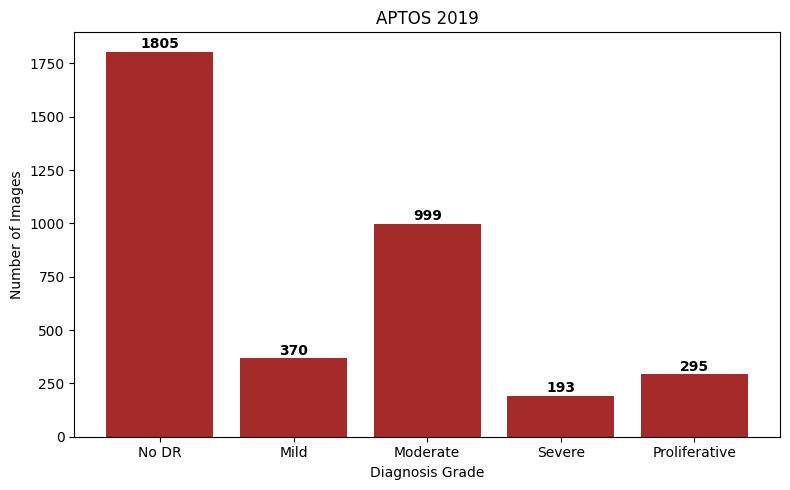

In [7]:
import matplotlib.pyplot as plt

grade_labels = {
    0: 'No DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferative'
}

counts = train_df['diagnosis'].value_counts().sort_index()
labels=[]
for i in counts.index:
  labels.append(grade_labels[i])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, counts.values, color='brown')
ax.set_xlabel('Diagnosis Grade')
ax.set_ylabel('Number of Images')
ax.set_title('APTOS 2019')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()



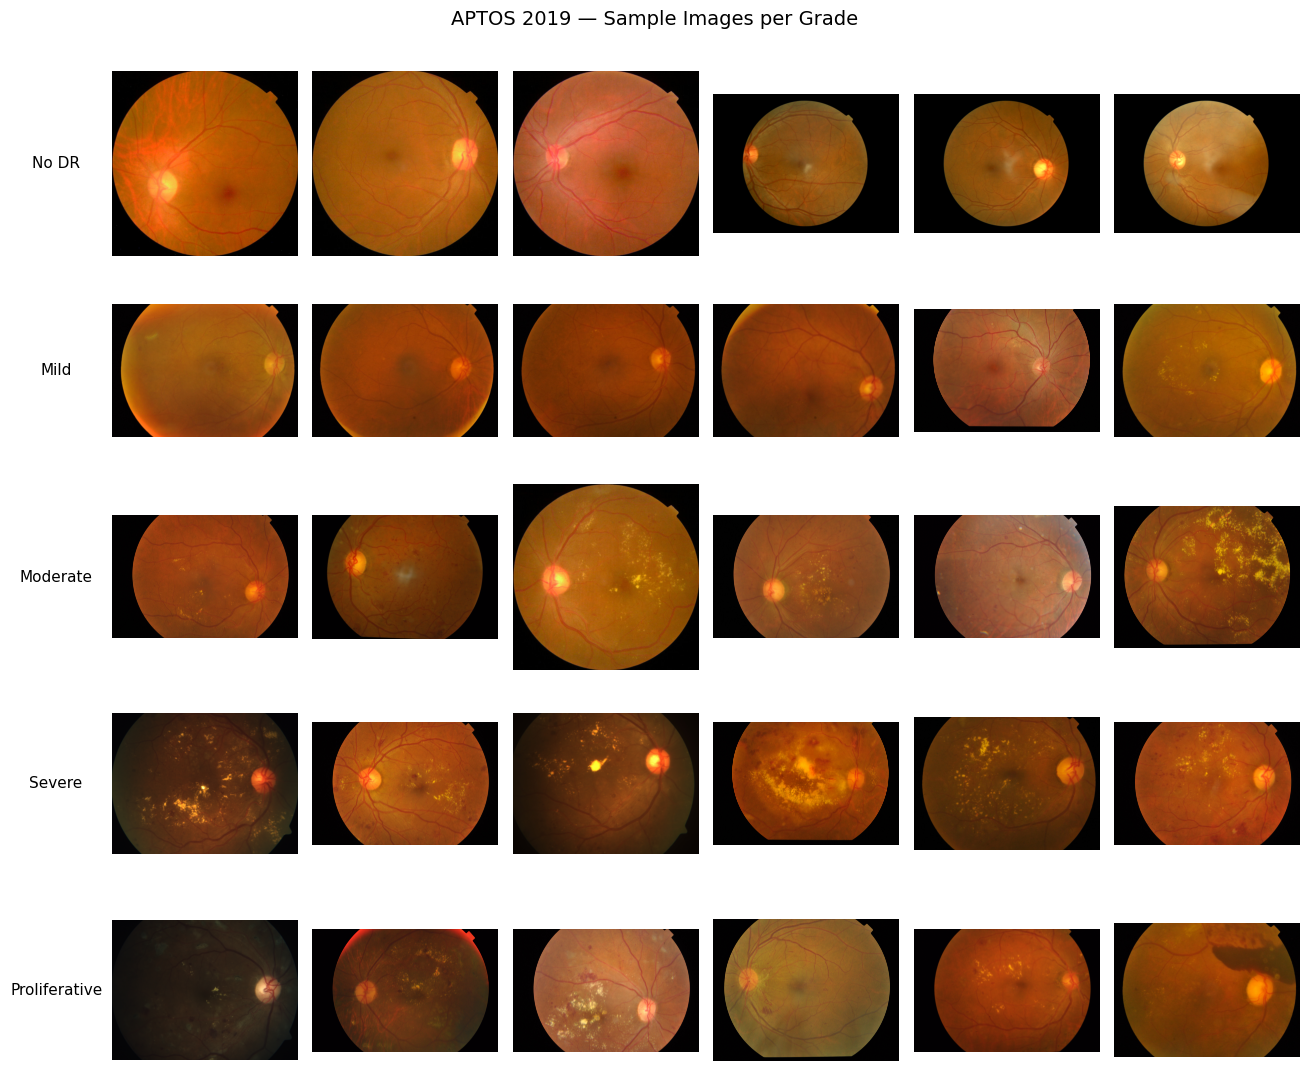

In [30]:
import numpy as np
from PIL import Image

n_samples = 6  # images per class
grades = sorted(grade_labels.keys())

fig, axes = plt.subplots(len(grades), n_samples, figsize=(n_samples * 2.2, len(grades) * 2.2))

rng = np.random.default_rng(42)  # reproducible sampling

for row, grade in enumerate(grades):
    # Get all image ids for this grade
    subset = train_df[train_df['diagnosis'] == grade]['id_code'].values
    sample_ids = rng.choice(subset, size=min(n_samples, len(subset)), replace=False)

    for col, img_id in enumerate(sample_ids):
        img_path = os.path.join(image_dir, f"{img_id}.png")
        img = Image.open(img_path)

        ax = axes[row, col]
        ax.imshow(img)
        ax.axis('off')

        if col == 0:
            ax.set_ylabel(grade_labels[grade], fontsize=11, rotation=0,
                          labelpad=40, va='center')
            ax.axis('on')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)

plt.suptitle('APTOS 2019 — Sample Images per Grade', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [9]:
from PIL import Image
import os

sizes = []

for img_id in train_df['id_code']:
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        sizes.append(img.size)

print("First 10 image sizes:")
print(sizes[:10])

print("\nUnique image sizes:")
print(len(set(sizes)))

First 10 image sizes:
[(3216, 2136), (3216, 2136), (2416, 1736), (1050, 1050), (2048, 1536), (3388, 2588), (2588, 1958), (3216, 2136), (2588, 1958), (2416, 1736)]

Unique image sizes:
17


In [10]:
modes = []

for img_id in train_df['id_code'].sample(100, random_state=42):
    path = os.path.join(image_dir, f"{img_id}.png")
    with Image.open(path) as img:
        modes.append(img.mode)

print(set(modes))

{'RGB'}


In [11]:
import sys
sys.path.append('/content/RetinaGrade/src/preprocessing')


from preprocessor import RetinaPreprocessor
from quality_checker import ImageQualityAssessor

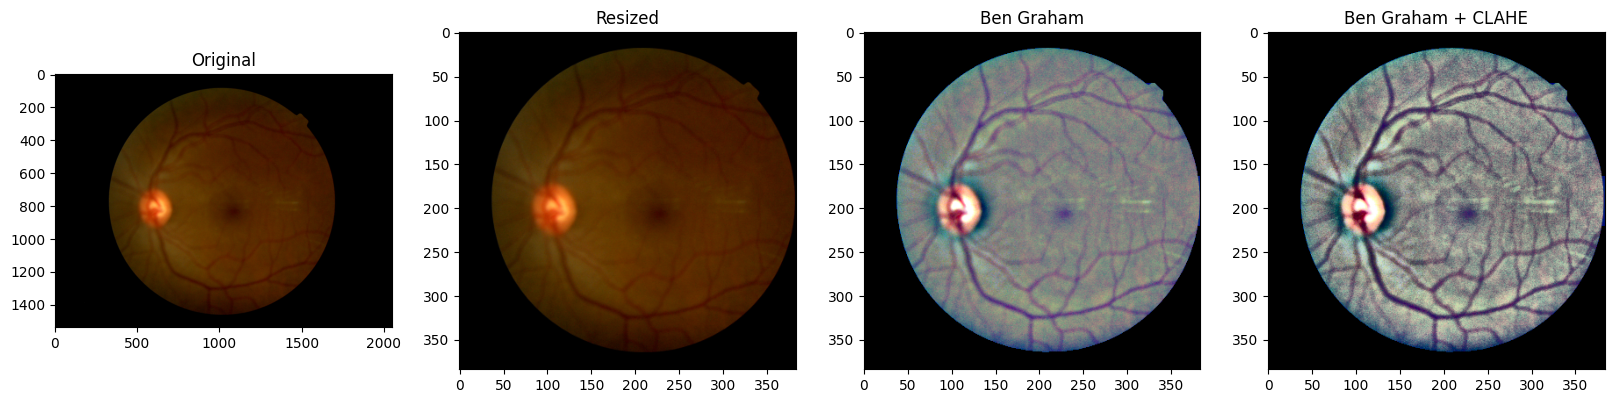

In [12]:
preprocessor = RetinaPreprocessor(img_size=384, ben_graham_sigma=10)
stages = preprocessor.preprocess_for_visualization('/content/RetinaGrade/data/train_images/005b95c28852.png')

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(stages['original']); axes[0].set_title('Original')
axes[1].imshow(stages['resized']); axes[1].set_title('Resized')
axes[2].imshow(stages['ben_graham']); axes[2].set_title('Ben Graham')
axes[3].imshow(stages['ben_graham_clahe']); axes[3].set_title('Ben Graham + CLAHE')
plt.show()

# **Add processed images**

In [35]:
import os
import cv2
import numpy as np
from tqdm import tqdm
import shutil


INPUT_DIR = '/content/RetinaGrade/data/train_images/'
GOOD_OUTPUT_DIR = '/content/RetinaGrade/data/processed_train_images/'
REJECTED_DIR = '/content/RetinaGrade/data/rejected_images/'

if os.path.exists(GOOD_OUTPUT_DIR):
    shutil.rmtree(GOOD_OUTPUT_DIR)
if os.path.exists(REJECTED_DIR):
    shutil.rmtree(REJECTED_DIR)

os.makedirs(GOOD_OUTPUT_DIR, exist_ok=True)
os.makedirs(REJECTED_DIR, exist_ok=True)

assessor = ImageQualityAssessor()
preprocessor = RetinaPreprocessor(img_size=300)

QUALITY_THRESHOLD = 0.25

valid_extensions = ('.png', '.jpg', '.jpeg')
all_images = [f for f in os.listdir(INPUT_DIR) if f.lower().endswith(valid_extensions)]

print(f" Starting processing of {len(all_images)} images with a lenient threshold ({QUALITY_THRESHOLD})...")

accepted_count = 0
rejected_count = 0

for img_name in tqdm(all_images, desc="Processing Images"):
    img_path = os.path.join(INPUT_DIR, img_name)
    img = cv2.imread(img_path)

    if img is None:
        continue

    score, issues = assessor.assess_quality(img)

    if score >= QUALITY_THRESHOLD:
        processed_img = preprocessor.preprocess_array(img, return_tensor=False, is_rgb=False)
        processed_img_uint8 = (processed_img * 255).astype(np.uint8)

        final_img_bgr = cv2.cvtColor(processed_img_uint8, cv2.COLOR_RGB2BGR)

        save_path = os.path.join(GOOD_OUTPUT_DIR, img_name)
        cv2.imwrite(save_path, final_img_bgr)
        accepted_count += 1

    else:
        dest_path = os.path.join(REJECTED_DIR, img_name)
        shutil.copy(img_path, dest_path)
        rejected_count += 1


print("\n" + "="*40)
print(" Process completed successfully!")
print(f" Total images: {len(all_images)}")
print(f" Accepted & Processed images: {accepted_count} (Saved to {GOOD_OUTPUT_DIR})")
print(f" Rejected images: {rejected_count} (Isolated to {REJECTED_DIR})")
print("="*40)

 Starting processing of 3662 images with a lenient threshold (0.25)...


Processing Images: 100%|██████████| 3662/3662 [12:21<00:00,  4.94it/s]


 Process completed successfully!
 Total images: 3662
 Accepted & Processed images: 3662 (Saved to /content/RetinaGrade/data/processed_train_images/)
 Rejected images: 0 (Isolated to /content/RetinaGrade/data/rejected_images/)


In [36]:
!ls data/processed_train_images | head


000c1434d8d7.png
001639a390f0.png
0024cdab0c1e.png
002c21358ce6.png
005b95c28852.png
0083ee8054ee.png
0097f532ac9f.png
00a8624548a9.png
00b74780d31d.png
00cb6555d108.png


In [13]:
from utils import load_data,data_split
import gc
x_train,y_train=load_data(df=train_df, image_dir="./data/processed_train_images")
x_train,x_val,x_test,y_train,y_val,y_test=data_split(x_train,y_train,val_size=0.15,test_size=0.1)



In [ ]:

print(y_train[0])

0


In [14]:
import torch
from model_builder import build_model
model=build_model(model_name="efficientnet_b3", num_classes=5, freeze_features=True)

device= "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [ ]:
print(len(model.features))

9


#Defining Weighted Loss

In [17]:
from Loss import FocalLoss
#convert to dict[] but i cant run it to test
W_loss=np.zeros(5)
for y in y_train:
  W_loss[y]+=1
W_loss=1/(W_loss/len(y_train))
W_loss=torch.tensor(W_loss,dtype=torch.float32).to(device)
# loss_function=nn.CrossEntropyLoss() #Remember to put it
loss_function=FocalLoss(gamma=2.0)


# Optimizer setup


In [20]:
import torch.optim as optim
import torch.utils.data as data
from augumentation import over_sample, train_transform,val_transform,apply_transform
from augumented_set import AugmentedDataset
from data_loading import create_dataloaders
#best lr: 1e-3
lr=1e-3
weight_decay=1e-4
optimizer=optim.Adam(model.classifier.parameters(),lr=lr, weight_decay=weight_decay)



train_loader,val_loader,test_loader =create_dataloaders(x_train,
                                                        y_train,
                                                        x_val, y_val,
                                                        x_test,
                                                        y_test,
                                                        targets={1: 2, 2: 2, 3: 7, 4: 5},
                                                        batch_size=32,
                                                        num_workers=4
                                                        )





/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
#  del x_train, y_train,
#  gc.collect()


#Training BaseLine


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 1/30 - train_loss: 0.9957 - val_loss: 0.4622
  val macro F1: 0.4816 | val QWK: 0.7561
  current LR: 1.00e-03
  -> Best model saved (max: 0.7561)
Epoch 2/30 - train_loss: 0.8043 - val_loss: 0.5390
  val macro F1: 0.3806 | val QWK: 0.7907
  current LR: 1.00e-03
  -> Best model saved (max: 0.7907)
Epoch 3/30 - train_loss: 0.8092 - val_loss: 0.3560
  val macro F1: 0.5528 | val QWK: 0.8175
  current LR: 1.00e-03
  -> Best model saved (max: 0.8175)
Epoch 4/30 - train_loss: 0.8374 - val_loss: 0.4467
  val macro F1: 0.4502 | val QWK: 0.7808
  current LR: 1.00e-03
Epoch 5/30 - train_loss: 0.7782 - val_loss: 0.3965
  val macro F1: 0.5175 | val QWK: 0.8030
  current LR: 1.00e-03
Epoch 6/30 - train_loss: 0.7544 - val_loss: 0.5194
  val macro F1: 0.4590 | val QWK: 0.7272
  current LR: 5.00e-04
Epoch 7/30 - train_loss: 0.6929 - val_loss: 0.3554
  val macro F1: 0.5113 | val QWK: 0.8129
  current LR: 5.00e-04
Epoch 8/30 - train_loss: 0.7033 - val_loss: 0.3617
  val macro F1: 0.4787 | val QWK: 0.

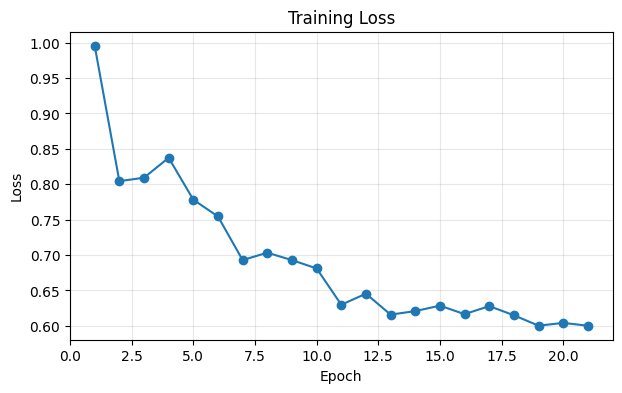

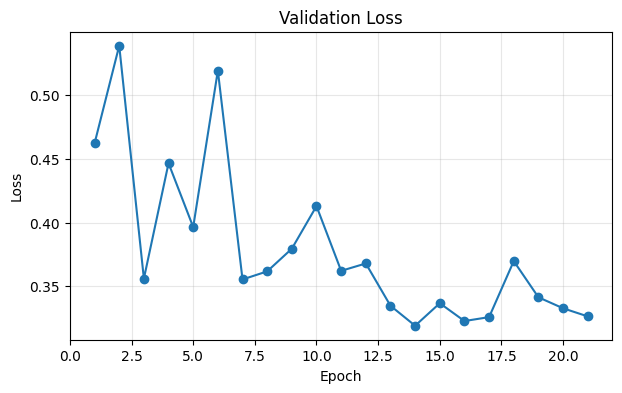

Accuracy:  0.7764
F1 (macro):     0.5842
Recall (macro): 0.5641
Precision (macro): 0.6328
QWK:       0.8327

Per-class report:
               precision    recall  f1-score   support

        No DR       0.94      0.95      0.95       271
         Mild       0.58      0.45      0.51        56
     Moderate       0.64      0.82      0.72       150
       Severe       0.43      0.31      0.36        29
Proliferative       0.57      0.30      0.39        44

     accuracy                           0.78       550
    macro avg       0.63      0.56      0.58       550
 weighted avg       0.77      0.78      0.76       550



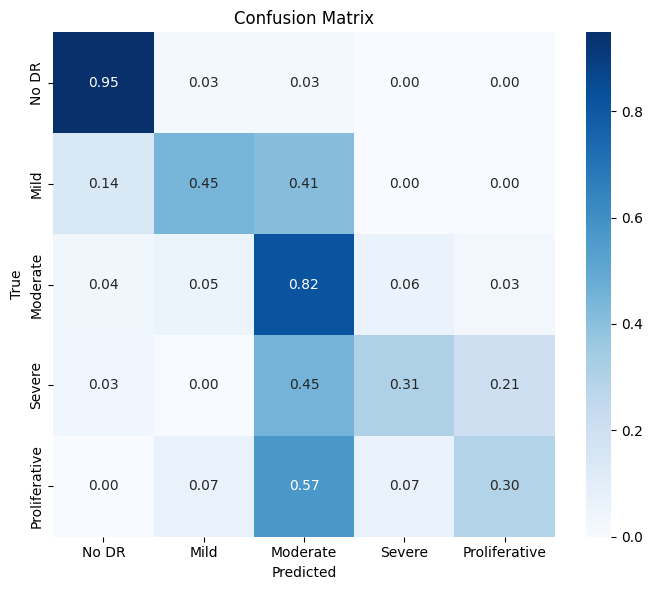

In [21]:
!pip install coral-pytorch -q
from evalution import evaluate_model, plot_training_curve, get_predictions, compute_metrics, compute_qwk
from early_stopper import EarlyStopping

import os
os.makedirs('/RetinaGrade/CheckPoint', exist_ok=True)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

early_stopper = EarlyStopping(patience=5, min_delta=0.001, path='/RetinaGrade/CheckPoint/best_model.pt', mode='max')

train_losses = []
val_losses = []
epoches = 30

for epoch in range(epoches):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epoches} "
        f"- train_loss: {avg_train_loss:.4f} "
        f"- val_loss: {avg_val_loss:.4f}"
    )

    y_pred, y_true = get_predictions(model, val_loader, device)
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f"  current LR: {current_lr:.2e}")

    early_stopper(val_qwk, model)

    if early_stopper.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper.best_score:.4f})")
        break

plot_training_curve(train_losses, title="Training Loss")
plot_training_curve(val_losses, title="Validation Loss")
metrics = evaluate_model(model, val_loader, device, average="macro")

In [ ]:
from LR_Tune import tune_learning_rates

lr_candidates = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]
tuning_results = tune_learning_rates(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    device=device,
    lrs=lr_candidates,
    epochs=6
)


--- Testing Learning Rate: 1e-05 ---


KeyboardInterrupt: 

#WD


In [ ]:
from WD_tune import tune_weight_decay

wd_candidates = [0, 1e-4, 1e-3, 1e-2, 5e-2]
tuning_results = tune_weight_decay(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    device=device,
    lr=1e-3,
    weight_decays=wd_candidates,
    epochs=6
)

# unfreeze


In [22]:
model.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model.pt'))

for layer_idx in [6, 7, 8]:
    for param in model.features[layer_idx].parameters():
        param.requires_grad = True

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")

optimizer = optim.Adam([
    {'params': model.classifier.parameters(), 'lr': 1e-4},
    {'params': model.features[6].parameters(), 'lr': 1e-5},
    {'params': model.features[7].parameters(), 'lr': 1e-5},
    {'params': model.features[8].parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
early_stopper = EarlyStopping(patience=10, min_delta=0.001, path='/RetinaGrade/CheckPoint/best_model_finetuned.pt', mode='max')

Trainable params: 8,513,764 / 10,703,918 (79.5%)


Epoch 1/40 - train_loss: 0.5878 - val_loss: 0.3215
  val macro F1: 0.6049 | val QWK: 0.8345
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8345)
Epoch 2/40 - train_loss: 0.5305 - val_loss: 0.2917
  val macro F1: 0.6088 | val QWK: 0.8686
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8686)
Epoch 3/40 - train_loss: 0.5050 - val_loss: 0.2780
  val macro F1: 0.6674 | val QWK: 0.8695
  current LR (classifier): 1.00e-04
Epoch 4/40 - train_loss: 0.4765 - val_loss: 0.2723
  val macro F1: 0.6577 | val QWK: 0.8783
  current LR (classifier): 1.00e-04
  -> Best model saved (max: 0.8783)
Epoch 5/40 - train_loss: 0.4386 - val_loss: 0.2614
  val macro F1: 0.6641 | val QWK: 0.8736
  current LR (classifier): 1.00e-04
Epoch 6/40 - train_loss: 0.4399 - val_loss: 0.2541
  val macro F1: 0.6533 | val QWK: 0.8742
  current LR (classifier): 1.00e-04
Epoch 7/40 - train_loss: 0.4220 - val_loss: 0.2502
  val macro F1: 0.6729 | val QWK: 0.8760
  current LR (classifier): 1.00e

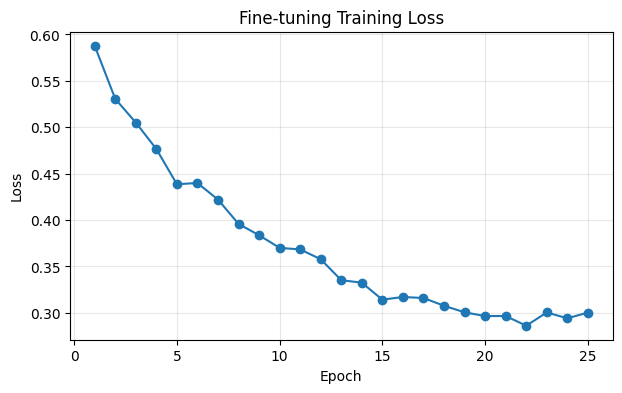

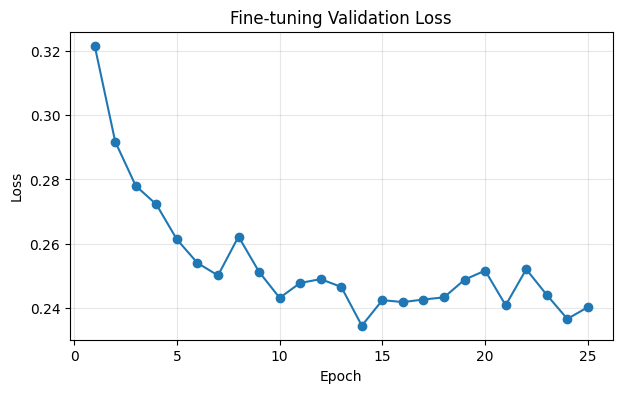

In [23]:

ft_train_losses = []
ft_val_losses = []
epoches =40

for epoch in range(epoches):

    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    ft_train_losses.append(avg_train_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_function(outputs, labels)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    ft_val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch + 1}/{epoches} "
        f"- train_loss: {avg_train_loss:.4f} "
        f"- val_loss: {avg_val_loss:.4f}"
    )

    y_pred, y_true = get_predictions(model, val_loader, device)
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler.step(avg_val_loss)
    current_lr_head = optimizer.param_groups[0]['lr']
    print(f"  current LR (classifier): {current_lr_head:.2e}")

    early_stopper(val_qwk, model)

    if early_stopper.early_stop:
      print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper.best_score:.4f})")
      break


model.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_finetuned.pt'))
print("The bset fine-tuning model is downloded successfully")


plot_training_curve(ft_train_losses, title="Fine-tuning Training Loss")
plot_training_curve(ft_val_losses, title="Fine-tuning Validation Loss")

# Ordinal Model (CORN)

In [24]:

import os
os.makedirs('/RetinaGrade/CheckPoint', exist_ok=True)

In [25]:
from coral_pytorch.losses import corn_loss
from evalution import evaluate_model_corn, plot_training_curve,get_predictions_corn
from early_stopper import EarlyStopping

model_corn = build_model(model_name="efficientnet_b3", num_classes=4, freeze_features=True)



model_corn.to(device)

optimizer_corn = optim.Adam(model_corn.classifier.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_corn = optim.lr_scheduler.ReduceLROnPlateau(optimizer_corn, mode='min', factor=0.5, patience=2)

early_stopper_corn = EarlyStopping(
    patience=5,
    min_delta=0.001,
    path='/RetinaGrade/CheckPoint/best_model_corn.pt',
    mode='max'
)


Epoch 1/20 - train_loss: 0.5214 - val_loss: 0.3836
  val macro F1: 0.3825 | val QWK: 0.7900
  current LR: 1.00e-03
  -> Best model saved (max: 0.7900)
Epoch 2/20 - train_loss: 0.4510 - val_loss: 0.3391
  val macro F1: 0.5135 | val QWK: 0.7775
  current LR: 1.00e-03
Epoch 3/20 - train_loss: 0.4323 - val_loss: 0.3327
  val macro F1: 0.4464 | val QWK: 0.8106
  current LR: 1.00e-03
  -> Best model saved (max: 0.8106)
Epoch 4/20 - train_loss: 0.4290 - val_loss: 0.3641
  val macro F1: 0.5623 | val QWK: 0.8336
  current LR: 1.00e-03
  -> Best model saved (max: 0.8336)
Epoch 5/20 - train_loss: 0.4358 - val_loss: 0.3514
  val macro F1: 0.4371 | val QWK: 0.8385
  current LR: 1.00e-03
  -> Best model saved (max: 0.8385)
Epoch 6/20 - train_loss: 0.4467 - val_loss: 0.3394
  val macro F1: 0.5017 | val QWK: 0.8101
  current LR: 5.00e-04
Epoch 7/20 - train_loss: 0.4121 - val_loss: 0.3270
  val macro F1: 0.5511 | val QWK: 0.8140
  current LR: 5.00e-04
Epoch 8/20 - train_loss: 0.3971 - val_loss: 0.3068


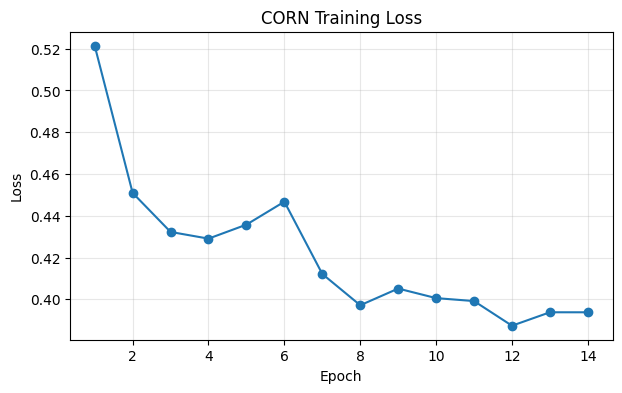

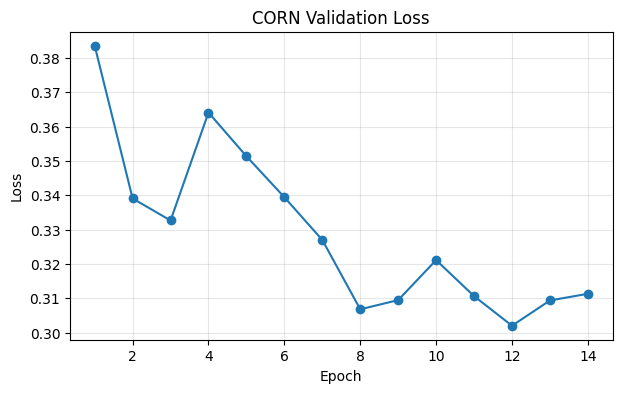

Accuracy:  0.7618
F1 (macro):     0.5735
Recall (macro): 0.5661
Precision (macro): 0.6039
QWK:       0.8532

Per-class report:
               precision    recall  f1-score   support

        No DR       0.95      0.94      0.94       271
         Mild       0.49      0.39      0.44        56
     Moderate       0.67      0.78      0.72       150
       Severe       0.29      0.38      0.33        29
Proliferative       0.62      0.34      0.44        44

     accuracy                           0.76       550
    macro avg       0.60      0.57      0.57       550
 weighted avg       0.76      0.76      0.76       550



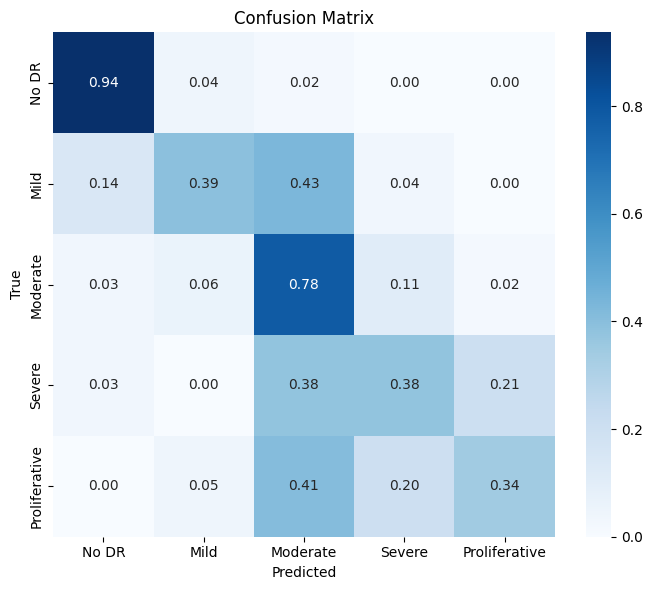

In [26]:
corn_val_losses = []
corn_train_losses = []
epoches = 20

for epoch in range(epoches):

    model_corn.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer_corn.zero_grad()
        logits = model_corn(images)
        loss = corn_loss(logits, labels, num_classes=len(grade_labels))
        loss.backward()
        optimizer_corn.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    corn_train_losses.append(avg_train_loss)

    model_corn.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model_corn(images)
            loss = corn_loss(logits, labels, num_classes=len(grade_labels))
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    corn_val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{epoches} - train_loss: {avg_train_loss:.4f} - val_loss: {avg_val_loss:.4f}")

    y_pred, y_true = get_predictions_corn(model_corn, val_loader, device, num_classes=len(grade_labels))
    val_metrics = compute_metrics(y_true, y_pred, average="macro")
    val_f1 = val_metrics["f1"]
    val_qwk = compute_qwk(y_true, y_pred)
    print(f"  val macro F1: {val_f1:.4f} | val QWK: {val_qwk:.4f}")

    scheduler_corn.step(avg_val_loss)
    current_lr = optimizer_corn.param_groups[0]['lr']
    print(f"  current LR: {current_lr:.2e}")

    early_stopper_corn(val_qwk, model_corn)
    if early_stopper_corn.early_stop:
        print(f"Early stopping triggered at epoch {epoch + 1} (best QWK: {early_stopper_corn.best_score:.4f})")
        break


model_corn.load_state_dict(torch.load('/RetinaGrade/CheckPoint/best_model_corn.pt'))
plot_training_curve(corn_train_losses, title="CORN Training Loss")
plot_training_curve(corn_val_losses, title="CORN Validation Loss")
final_metrics = evaluate_model_corn(model_corn, val_loader, device, average="macro", plot=True)